# World Bank Development Indicators

Population, land area, national accounts, prices, rates and fiscal aggregates for every country the
World Bank reports, pulled from its API through `kuznets`. One panel, because these are one
country-year grid from one API.

## Provenance

These are the fields of the `WORLD_BANK` declaration in `climate_risk/data/world_bank.py`. It is an
`ApiSource`, so it carries an endpoint rather than a filename. The API answers a query rather than
serving a file, so no raw download is cached. The processed panel still is.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.world_bank import WORLD_BANK

declared = {"publisher": "World Bank"} | dataclasses.asdict(WORLD_BANK)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | World Bank |
| url | https://api.worldbank.org/v2/country |
| license | CC BY 4.0 |
| citation | World Bank, World Development Indicators, https://databank.worldbank.org/source/world-development-indicators. |
| retrieved | 2026-09-05 |

## Loading it

`load_wb_data` returns the panel. The cache directory is your choice, and this page uses one named
`data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

import climate_risk as cr

from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

indicators = cr.load_wb_data(cache_dir)

## What you get

A polars frame, one row per country and year, with 24 indicators. Every column is an indicator
under a readable name rather than a World Bank code.

In [4]:
indicators.head()

country_code,year,population_density,gdp_per_cap_usd,population,real_gdp_usd,surface_area_km2,real_gdp_lcu,real_consumption_lcu,real_investment_lcu,real_government_lcu,real_exports_lcu,real_imports_lcu,nominal_consumption,nominal_investment,cpi,gdp_deflator,exchange_rate,lending_rate,deposit_rate,import_tariff,external_debt,current_account_gdp,employment_rate,tax_revenue_gdp,government_expense_gdp
str,i64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABW""",1960,null,null,54922,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ABW""",1961,308.766667,null,55578,null,180.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ABW""",1962,312.888889,null,56320,null,180.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ABW""",1963,316.677778,null,57002,null,180.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ABW""",1964,320.105556,null,57619,null,180.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


## Units

| Column | Unit |
|---|---|
| `country_code` | ISO 3166-1 alpha-3 country code |
| `year` | calendar year |
| `population_density` | people per square kilometer of land area |
| `gdp_per_cap_usd` | constant 2015 US dollars |
| `population` | people |
| `real_gdp_usd` | constant 2015 US dollars |
| `surface_area_km2` | square kilometers |
| `real_gdp_lcu` | constant local currency |
| `real_consumption_lcu` | constant local currency |
| `real_investment_lcu` | constant local currency |
| `real_government_lcu` | constant local currency |
| `real_exports_lcu` | constant local currency |
| `real_imports_lcu` | constant local currency |
| `nominal_consumption` | current local currency |
| `nominal_investment` | current local currency |
| `cpi` | index, 2010 = 100 |
| `gdp_deflator` | index, base year set per country |
| `exchange_rate` | local currency per US dollar, period average |
| `lending_rate` | percent per year |
| `deposit_rate` | percent per year |
| `import_tariff` | percent, weighted mean applied rate on all products |
| `external_debt` | current US dollars |
| `current_account_gdp` | percent of GDP |
| `employment_rate` | percent of the population aged 15 and over |
| `tax_revenue_gdp` | percent of GDP |
| `government_expense_gdp` | percent of GDP |

A name ending `_usd` is constant 2015 US dollars and one ending `_lcu` is constant local currency,
so the price base is readable off the column. The constant local currency base year is set by each
country's own national accounts, which is why an `_lcu` level means nothing across countries. The
rest come from the Bank's indicator documentation, not from anything the cache carries.

## Coverage

Twenty-four indicators in one frame with one common unit between them, so `describe` is read a row
at a time. It is transposed to make that the reading direction. The null counts are the point: this
panel is not rectangular.

In [5]:
with pl.Config(tbl_rows=30, tbl_cols=-1):
    display(
        indicators.drop("country_code", "year")
        .describe()
        .transpose(include_header=True, header_name="indicator", column_names="statistic")
    )

indicator,count,null_count,mean,std,min,25%,50%,75%,max
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""population_density""",11973.0,1953.0,231.615624,1160.141063,0.098625,19.796422,65.246476,151.102174,18822.890972
"""gdp_per_cap_usd""",11311.0,2615.0,12260.542137,19429.561945,122.678901,1342.019261,3967.333876,15320.358383,247170.103807
"""population""",13926.0,0.0,2.6102e7,1.0766e8,2715.0,539388.0,4.390246e6,1.4912631e7,1.4639e9
"""real_gdp_usd""",11311.0,2615.0,2.5123e11,1.1948e12,1.0077e7,3.4793e9,1.5092e10,9.3473e10,2.3223e13
"""surface_area_km2""",13058.0,868.0,674610.641771,2.0306e6,2.027,13810.0,109880.0,475440.0,1.712519e7
"""real_gdp_lcu""",11401.0,2525.0,2.8017e14,3.3918e15,1.4539828e7,2.0328e10,2.9743e11,3.0105e12,8.0831e16
"""real_consumption_lcu""",7232.0,6694.0,1.9120e14,1.8497e15,3.6747834e7,3.7792e10,4.4307e11,2.8948e12,3.2633e16
"""real_investment_lcu""",6743.0,7183.0,1.9137e14,1.9116e15,-5.5462e8,1.3481e10,1.4272e11,1.0980e12,3.8353e16
"""real_government_lcu""",7168.0,6758.0,7.2293e13,7.2492e14,5.8769e6,1.2893e10,1.0856e11,7.1148e11,1.0222e16


## A plot

How many countries report GDP per capita in each year. The rise is countries beginning to report,
and the fall at the right edge is the Bank not having finished collecting the most recent years.
Both ends of this curve are traps for anything that assumes a balanced panel.

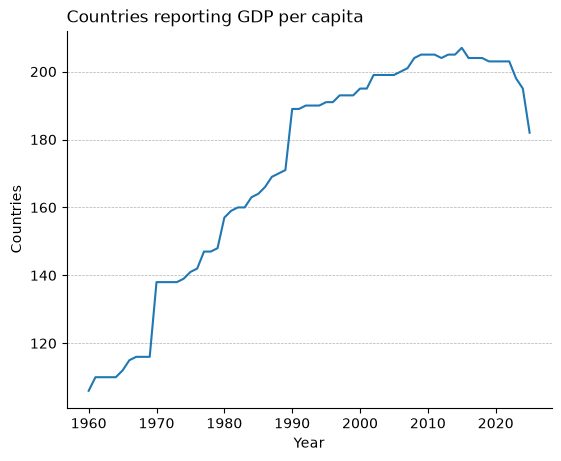

In [6]:
reporting = (
    indicators.group_by("year").agg(pl.col("gdp_per_cap_usd").is_not_null().sum().alias("countries")).sort("year")
)

figure, axis = plt.subplots(figsize=(5.5, 4.5))
axis.plot(reporting["year"], reporting["countries"], color=PALETTE["primary"])
axis.set_title("Countries reporting GDP per capita", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Countries")

plt.show()

## Gotchas

*The panel is not balanced, at either end.* A fifth of the `gdp_per_cap_usd` and `real_gdp_usd`
cells are null, and the fiscal and rate series are far emptier than that. Dropping incomplete rows
silently discards the early decades, the most recent ones, and most of the countries.

*Two price bases sit side by side.* `real_gdp_usd` and `real_gdp_lcu` are the same quantity in
different currencies. Ratios formed within a country want the local-currency series, and levels
compared across countries want the dollar one. Mixing them is a unit error nothing downstream can
see, which is why the price base is in the name.

*Regional and income aggregates are excluded.* The Bank returns rows for groupings like "Sub-Saharan
Africa" and "Low income" alongside countries. `world_bank_countries.csv` carries a `requested` flag
that leaves them out, so a total over this frame is a total over countries.

*`year` is a deliberate `Int64`.* `dt.year()` narrows to `Int32`, and a join key that changes width
is a join that stops matching. Anything joining onto this panel wants the same width.

*A retired indicator code raises here rather than going missing.* `kuznets` warns and omits the
column, which would otherwise reach the panel as an indicator that is simply absent.